In [1]:
import os
import sys
from pathlib import Path
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_NUM_INTRAOP_THREADS"] = "2"
os.environ["TF_NUM_INTEROP_THREADS"] = "2"
os.environ["OMP_NUM_THREADS"] = "2"
project_directory = Path.cwd()
if not (project_directory / "common.py").is_file():
    project_directory = project_directory.parent
sys.path.insert(0, str(project_directory))
from common import ROOT, MODE, SEED, BATCH, EPOCHS, CLASSES, ensure_data, split_paths, seed_all, load_array, evaluate_binary, save_metrics
seed_all()
print(f"Project: {ROOT.name} | mode: {MODE} | seed: {SEED}")


Project: land-classification-github | mode: quick | seed: 7331


In [2]:
import torch
import matplotlib.pyplot as plt
from torch_models import ConvNet, make_loader, fit_model, predict_probabilities
torch.set_num_threads(2)
torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
train, val, test = split_paths()
train_loader = make_loader(*train, augment=True, shuffle=True, batch=BATCH)
val_loader = make_loader(*val, batch=BATCH)
test_loader = make_loader(*test, batch=BATCH)
model = ConvNet()
print("Device:", device, "| train samples:", len(train[1]), "| parameters:", sum(p.numel() for p in model.parameters()))


Device: cpu | train samples: 336 | parameters: 23714


In [3]:
history = fit_model(model, train_loader, val_loader, epochs=EPOCHS, device=device)
checkpoint = ROOT / "models" / "pytorch_cnn.pth"
checkpoint.parent.mkdir(parents=True, exist_ok=True)
torch.save(model.cpu().state_dict(), checkpoint)
probabilities = predict_probabilities(model, test_loader, device=device)
metrics = evaluate_binary(test[1], probabilities)
print("Test metrics:", {name: value for name, value in metrics.items() if isinstance(value, (float, int))})
print(metrics["classification_report"])
print("Saved:", checkpoint.relative_to(ROOT), save_metrics("pytorch_cnn", metrics).relative_to(ROOT))


Epoch 1/2 | train acc 0.610 | val acc 0.694 | val loss 0.633
Epoch 2/2 | train acc 0.821 | val acc 0.861 | val loss 0.493
Test metrics: {'n_test': 72, 'accuracy': 0.8611111111111112, 'precision': 1.0, 'recall': 0.7222222222222222, 'f1': 0.8387096774193549, 'roc_auc': 0.9251543209876543, 'log_loss': 0.45160506075517076}
                  precision    recall  f1-score   support

class_0_non_agri       0.78      1.00      0.88        36
    class_1_agri       1.00      0.72      0.84        36

        accuracy                           0.86        72
       macro avg       0.89      0.86      0.86        72
    weighted avg       0.89      0.86      0.86        72

Saved: models/pytorch_cnn.pth results/pytorch_cnn.json


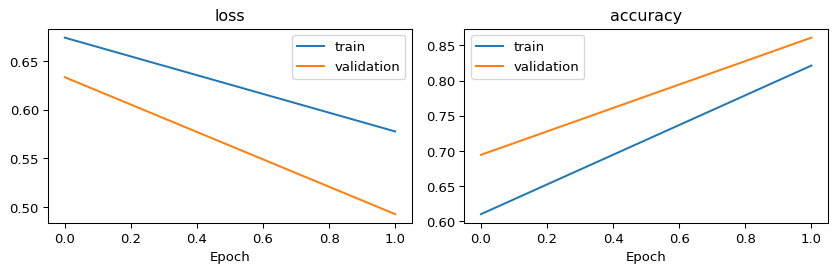

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
for axis, metric in zip(axes, ("loss", "accuracy")):
    axis.plot(history[metric], label="train")
    axis.plot(history["val_" + metric], label="validation")
    axis.set(xlabel="Epoch", title=metric)
    axis.legend()
plt.tight_layout()
plt.show()
